In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('dataf.csv')

In [3]:
df=df.drop(columns=['Unnamed: 0.1','Unnamed: 0'])

In [4]:
df=df.dropna()

In [5]:
df

,h3_cell,date,future_accidents,label,accidents_today,speed_limit,road_type,first_road_class,first_road_number,junction_detail,...,road_surface_conditions,weather_conditions,light_conditions,carriageway_hazards,urban_or_rural_area,day_of_week,month,is_weekend,acc_last_7,acc_last_30
1,8809a44713fffff,2020-01-02,0,0,0,20,9,6,0,0,...,1,1,1,0,2,3,1,0,0.0,0.0
2,8809a44713fffff,2020-01-03,0,0,0,20,9,6,0,0,...,1,1,1,0,2,4,1,0,0.0,0.0
3,8809a44713fffff,2020-01-04,0,0,0,20,9,6,0,0,...,1,1,1,0,2,5,1,1,0.0,0.0
4,8809a44713fffff,2020-01-05,0,0,0,20,9,6,0,0,...,1,1,1,0,2,6,1,1,0.0,0.0
5,8809a44713fffff,2020-01-06,0,0,0,20,9,6,0,0,...,1,1,1,0,2,0,1,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36399995,881943a11dfffff,2024-12-20,0,0,0,30,6,4,1101,13,...,1,1,1,0,1,4,12,0,0.0,0.0
36399996,881943a11dfffff,2024-12-21,0,0,0,30,6,4,1101,13,...,1,1,1,0,1,5,12,1,0.0,0.0
36399997,881943a11dfffff,2024-12-22,0,0,0,30,6,4,1101,13,...,1,1,1,0,1,6,12,1,0.0,0.0
36399998,881943a11dfffff,2024-12-23,0,0,0,30,6,4,1101,13,...,1,1,1,0,1,0,12,0,0.0,0.0


In [6]:
df.isnull().sum()

h3_cell                    0
date                       0
future_accidents           0
label                      0
accidents_today            0
speed_limit                0
road_type                  0
first_road_class           0
first_road_number          0
junction_detail            0
junction_control           0
second_road_class          0
second_road_number         0
pedestrian_crossing        0
road_surface_conditions    0
weather_conditions         0
light_conditions           0
carriageway_hazards        0
urban_or_rural_area        0
day_of_week                0
month                      0
is_weekend                 0
acc_last_7                 0
acc_last_30                0
dtype: int64

In [7]:
df.columns

Index(['h3_cell', 'date', 'future_accidents', 'label', 'accidents_today',
       'speed_limit', 'road_type', 'first_road_class', 'first_road_number',
       'junction_detail', 'junction_control', 'second_road_class',
       'second_road_number', 'pedestrian_crossing', 'road_surface_conditions',
       'weather_conditions', 'light_conditions', 'carriageway_hazards',
       'urban_or_rural_area', 'day_of_week', 'month', 'is_weekend',
       'acc_last_7', 'acc_last_30'],
      dtype='object')

In [8]:
feature_cols=[ 'accidents_today','acc_last_7', 'acc_last_30', 'day_of_week', 'month', 'is_weekend', 'speed_limit', 'road_type', 'junction_control', 'pedestrian_crossing', 'urban_or_rural_area', 'weather_conditions']

In [9]:
df['date'].info()

<class 'pandas.core.series.Series'>
Index: 36399999 entries, 1 to 36399999
Series name: date
Non-Null Count     Dtype 
--------------     ----- 
36399999 non-null  object
dtypes: object(1)
memory usage: 555.4+ MB


In [10]:
df['date']=pd.to_datetime(df['date'])

In [11]:
split_data=df['date'].quantile(0.8)

In [12]:
train_data=df[df['date']<=split_data].copy()
test_data=df[df['date']>split_data].copy()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36399999 entries, 1 to 36399999
Data columns (total 24 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   h3_cell                  object        
 1   date                     datetime64[ns]
 2   future_accidents         int64         
 3   label                    int64         
 4   accidents_today          int64         
 5   speed_limit              int64         
 6   road_type                int64         
 7   first_road_class         int64         
 8   first_road_number        int64         
 9   junction_detail          int64         
 10  junction_control         int64         
 11  second_road_class        int64         
 12  second_road_number       int64         
 13  pedestrian_crossing      int64         
 14  road_surface_conditions  int64         
 15  weather_conditions       int64         
 16  light_conditions         int64         
 17  carriageway_hazards      int64

In [14]:
%%time
x_train=train_data[feature_cols]
y_train=train_data['label']
x_test=test_data[feature_cols]
y_test=test_data['label']

CPU times: user 312 ms, sys: 906 ms, total: 1.22 s
Wall time: 1.94 s


In [16]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
dtrain=xgb.DMatrix(x_train,label=y_train,feature_names=feature_cols)
dval=xgb.DMatrix(x_test,label=y_test,feature_names=feature_cols)

In [18]:
pos=y_train.sum()
neg=y_train.shape[0]-pos
scale_pos_weight=neg/(pos+1e-9) if pos>0 else 1

In [21]:
params={
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.05,                      
    'max_depth': 8,
    'subsample': 0.8,                 
    'colsample_bytree': 0.8,         
    'seed': 42,
    'tree_method': 'hist',      
    'scale_pos_weight': scale_pos_weight,
    'verbosity': 1                  
}

In [22]:
evallist=[(dtrain,'train'),(dval,'valid')]

In [23]:
bst=xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evallist,
    early_stopping_rounds=30,
    verbose_eval=25
)

[0]	train-auc:0.72278	valid-auc:0.72385
[25]	train-auc:0.74288	valid-auc:0.73759
[50]	train-auc:0.74412	valid-auc:0.73788
[72]	train-auc:0.74486	valid-auc:0.73788


In [26]:
y_pred=bst.predict(dval,iteration_range=(0, bst.best_iteration + 1))
auc=roc_auc_score(y_test,y_pred)
ap=average_precision_score(y_test,y_pred)
print(f"AUC:{auc:.4f},AveragePrecision(PR-AUC):{ap:.4f}")

AUC:0.7380,AveragePrecision(PR-AUC):0.0687


In [56]:
test_df = test_data.copy()
test_df['score'] = y_pred
cell_scores = test_df.groupby('h3_cell')['score'].mean().reset_index()
cell_labels = test_df.groupby('h3_cell')['label'].max().reset_index()
eval_df = cell_scores.merge(cell_labels, on='h3_cell')
K=1000
K = min(K, len(eval_df))
precision_at_k = eval_df.nlargest(K, 'score')['label'].sum() / float(K)
print(f"Precision@{K}: {precision_at_k:.4f}")

Precision@1000: 0.9790


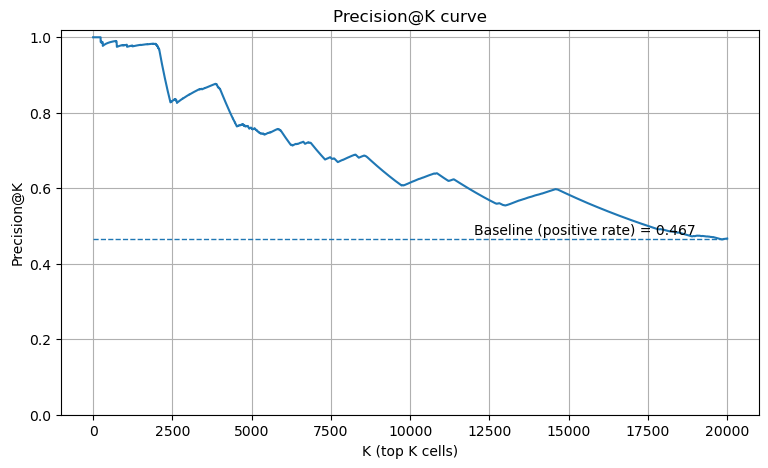

Precision@10: 1.0000
Precision@20: 1.0000
Precision@50: 1.0000
Precision@100: 1.0000
Precision@200: 1.0000
Precision@1000: 0.9790
Average Precision (AP): 0.7439


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

def precision_at_k_curve(scores, labels, max_k=None, step=1):
    """
    Compute Precision@K for K = 1, 1+step, 1+2*step, ..., max_k.
    - scores: array-like predicted scores (higher = more risky)
    - labels: array-like true binary labels (0/1)
    - max_k: int or None. If None, uses len(scores)
    - step: integer step for K (use >1 for speed on large datasets)
    Returns: (ks, precisions) where ks is array of K values, precisions same shape.
    """
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    if scores.shape[0] != labels.shape[0]:
        raise ValueError("scores and labels must have the same length")

    order = np.argsort(scores)[::-1]              # descending by score
    labels_sorted = labels[order]
    n = len(labels_sorted)
    if max_k is None:
        max_k = n
    max_k = min(max_k, n)

    ks = np.arange(1, max_k + 1, step)
    cumsum_tp = np.cumsum(labels_sorted)
    precisions = cumsum_tp[ks - 1] / ks.astype(float)

    return ks, precisions


scores = eval_df['score'].values
labels = eval_df['label'].values

ks, precisions = precision_at_k_curve(scores, labels, max_k=len(scores), step=1)


plt.figure(figsize=(9,5))
plt.plot(ks, precisions)            
plt.xlabel('K (top K cells)')
plt.ylabel('Precision@K')
plt.title('Precision@K curve')
plt.grid(True)
plt.ylim(0, 1.02)

baseline = labels.mean()
plt.hlines(baseline, xmin=ks.min(), xmax=ks.max(), linestyles='dashed', linewidth=1)
plt.text(ks.max()*0.6, baseline + 0.01, f'Baseline (positive rate) = {baseline:.3f}')

plt.show()

for K in [10, 20, 50, 100, int(0.01*len(scores)), int(0.05*len(scores))]:
    if K <= 0:
        continue
    K = min(K, len(scores))
    prec_at_k = (labels[np.argsort(scores)[::-1]][:K].sum()) / float(K)
    print(f"Precision@{K}: {prec_at_k:.4f}")

ap = average_precision_score(labels, scores)
print(f"Average Precision (AP): {ap:.4f}")


In [41]:
import glob, os, joblib
encoders = {}
MODEL_PATH = "xgb_hotspot.model"
ENC_PATH = "xgb_encoders.joblib"
bst.save_model(MODEL_PATH)
joblib.dump({'feature_cols': feature_cols, 'encoders': encoders, 'params': params}, ENC_PATH)
print("Saved model to", MODEL_PATH, "and encoders to", ENC_PATH)

fi = bst.get_score(importance_type='gain')
fi_sorted = sorted(fi.items(), key=lambda x: x[1], reverse=True)
print("Top features by gain:", fi_sorted[:15])

Saved model to xgb_hotspot.model and encoders to xgb_encoders.joblib
Top features by gain: [('urban_or_rural_area', 792102.4375), ('acc_last_30', 7704.869140625), ('weather_conditions', 4010.66552734375), ('speed_limit', 3936.84765625), ('road_type', 2930.7998046875), ('junction_control', 2117.2880859375), ('month', 631.4363403320312), ('pedestrian_crossing', 567.7061767578125), ('acc_last_7', 506.0451965332031), ('accidents_today', 458.80987548828125), ('day_of_week', 26.812421798706055), ('is_weekend', 22.475038528442383)]


/var/folders/qt/8w5zy69d4c3_bvqdvxnrx3fw0000gn/T/ipykernel_16577/2542251431.py:5: UserWarning: [13:29:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  bst.save_model(MODEL_PATH)


In [57]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc  = roc_auc_score(y_test, y_pred)
ap   = average_precision_score(y_test, y_pred)

print(f"ROC-AUC: {auc:.4f}")
print(f"PR-AUC:  {ap:.4f}")

test_df['score'] = y_pred

cell_scores = test_df.groupby('h3_cell')['score'].mean().reset_index()
cell_labels = test_df.groupby('h3_cell')['label'].max().reset_index()

eval_df = cell_scores.merge(cell_labels, on='h3_cell')

K = 50   
precision_at_k = eval_df.nlargest(K, 'score')['label'].sum() / K
print(f"Precision@{K}: {precision_at_k:.4f}")

total_positives = eval_df['label'].sum()
hit_rate = eval_df.nlargest(K, 'score')['label'].sum() / total_positives
print(f"HitRate@{K}: {hit_rate:.4f}")


ROC-AUC: 0.7380
PR-AUC:  0.0687
Precision@50: 1.0000
HitRate@50: 0.0054
